In [76]:
import math
class Value:
    def __init__(self, data,_children=(),_op='',label=''):
        self.data = data
        self._prev = _children
        self.label = label
        self._op = _op
        self.grad = 0.0
        self._backward = lambda:None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
            
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __sub__(self, other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other):
        return self * other**-1
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for n in reversed(topo):
            print(n.label, n._op, n.grad)
            n._backward()

    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out



In [77]:
a = Value(2,label='a')
b = Value(3,label='b')

c= a+b;c.label = 'c'
c

Value(data=5)

In [78]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


from graphviz import Digraph

def draw_dot(root):
    nodes,edgees = trace(root)
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'})
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid + n._op,label=n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edgees:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)
    return dot

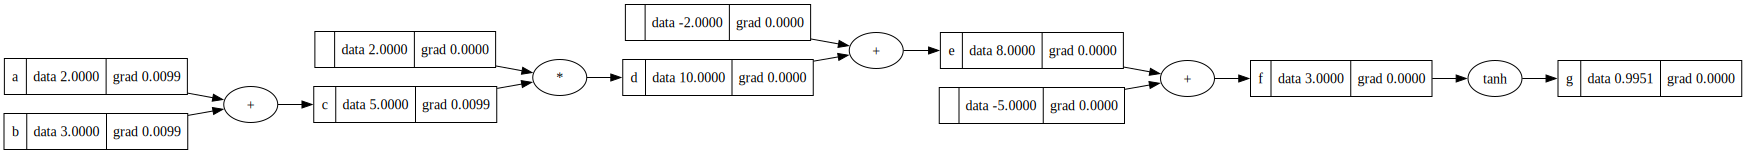

In [92]:
d = c * 2 ; d.label = "d"
e = d-2; e.label = "e"
f = e-5; f.label = "f"
g = f.tanh();g.label = "g"
draw_dot(g)

g tanh 1.0
f + 0.009866037165440211
  0.009866037165440211
e + 0.009866037165440211
  0.009866037165440211
d * 0.009866037165440211
  0.049330185827201056
c + 0.02959856163691832
b  0.0394654990835539
a  0.0394654990835539


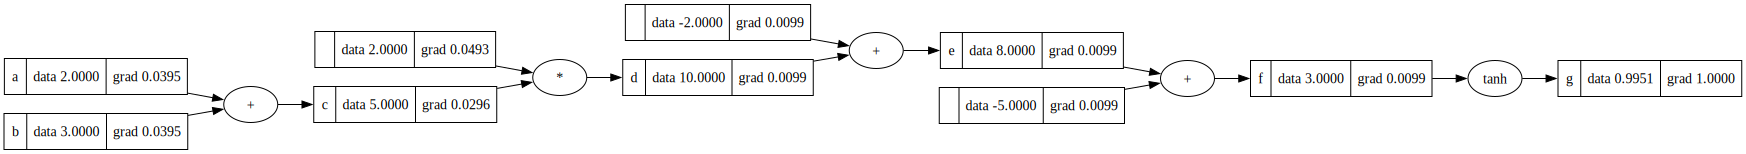

In [93]:
g.backward()
draw_dot(g)


In [83]:
print("f.data =", f.data)
print("g.data =", g.data)
print("tanh derivative =", 1 - g.data**2)

f.data = 500
g.data = 1.0
tanh derivative = 0.0


In [115]:
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out
    

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for i in range(nout)]

    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        return out
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)

        return x
        

In [116]:
x = [2,3]
n = MLP(2,[1,2,3])
n(x)

[Value(data=-0.8482088608646172),
 Value(data=-0.7972575266394795),
 Value(data=0.31171011307907187)]

In [113]:
nin,nouts = 2,[1,2,3]
sz = [nin] + nouts
sz

[2, 1, 2, 3]

In [118]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

[Value(data=-0.5056343735272717)]

In [121]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

y_pred = [n(x) for x in xs]
y_pred

[[Value(data=-0.5056343735272717)],
 [Value(data=-0.43905660567993243)],
 [Value(data=0.34891192559922296)],
 [Value(data=0.2740385378445637)]]